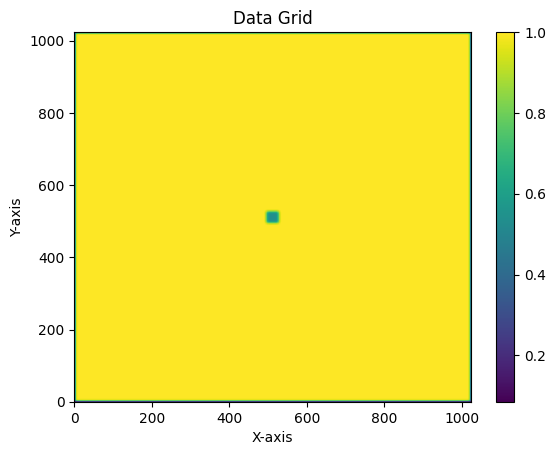

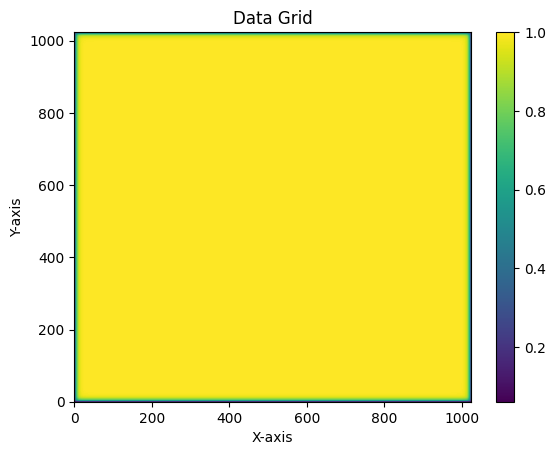

In [13]:
import numpy as np
import matplotlib.pyplot as plt

N = 1024

# Read binary file
#data = np.fromfile('output_u.txt', dtype=np.float32)
data = np.loadtxt('output_u.txt')
# Check if the number of elements matches 1024 x 1024
#if data.size != 1024 * 1024:
#    raise ValueError("Data size does not match 1024 x 1024")

# Reshape the data
data_initial = data[0, :].reshape((N, N))
data_final = data[-1, :].reshape((N, N))

# Plot the data as a grid
plt.pcolormesh(data_initial, cmap='viridis')
plt.colorbar()
plt.title('Data Grid')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()


plt.pcolormesh(data_final, cmap='viridis')
plt.colorbar()
plt.title('Data Grid')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()

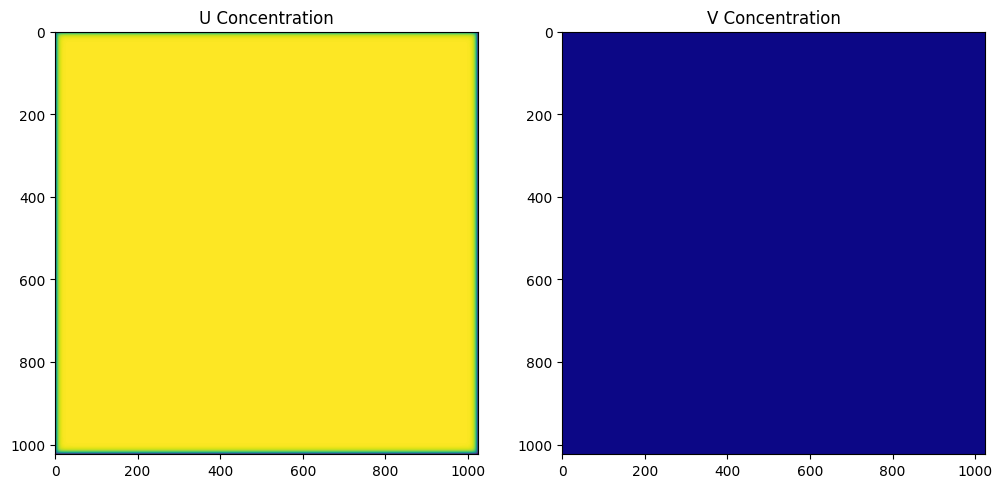

In [17]:
%matplotlib inline
from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Assuming 'data_u.txt' and 'data_v.txt' are the files with values for u and v respectively
u_data = np.loadtxt('output_u.txt')
v_data = np.loadtxt('output_v.txt')

# Get the number of timesteps (lines in the file)
timesteps = u_data.shape[0]

# Reshape each line into a grid (adjust grid size as needed, e.g., 64x64)
grid_size = (1024, 1024)  # Example grid size, modify according to your data
u_data = u_data.reshape((timesteps, *grid_size))
v_data = v_data.reshape((timesteps, *grid_size))

# Set up the figure and axis
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Initialize the plots
u_plot = ax[0].imshow(u_data[0], cmap='viridis', vmin=u_data.min(), vmax=u_data.max())
v_plot = ax[1].imshow(v_data[0], cmap='plasma', vmin=v_data.min(), vmax=v_data.max())

# Set titles
ax[0].set_title('U Concentration')
ax[1].set_title('V Concentration')

# Function to update the plot at each frame
def update(frame):
    u_plot.set_data(u_data[frame])
    v_plot.set_data(v_data[frame])
    return u_plot, v_plot

# Create the animation
anim = FuncAnimation(fig, update, frames=timesteps, interval=100, blit=True)

# Display the animation
HTML(anim.to_jshtml())



In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Load the data from the files
u_data = np.loadtxt('data_u.txt')
v_data = np.loadtxt('data_v.txt')

# Get the number of timesteps (lines in the file)
timesteps = u_data.shape[0]

# Reshape each line into a grid (adjust grid size as needed, e.g., 64x64)
grid_size = (64, 64)  # Example grid size, modify according to your data
u_data = u_data.reshape((timesteps, *grid_size))
v_data = v_data.reshape((timesteps, *grid_size))

# Set up the figure and axis
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Initialize the scatter plots
u_plot = ax[0].scatter([], [])
v_plot = ax[1].scatter([], [])

# Set titles
ax[0].set_title('U Concentration')
ax[1].set_title('V Concentration')

# Function to update the plot at each frame
def update(frame):
    ax[0].clear()
    ax[1].clear()
    ax[0].set_title('U Concentration')
    ax[1].set_title('V Concentration')
    u_plot = ax[0].scatter(np.arange(grid_size[0]), np.arange(grid_size[1]), c=u_data[frame].flatten(), cmap='viridis')
    v_plot = ax[1].scatter(np.arange(grid_size[0]), np.arange(grid_size[1]), c=v_data[frame].flatten(), cmap='plasma')
    return u_plot, v_plot

# Create the animation
anim = FuncAnimation(fig, update, frames=timesteps, interval=100, blit=True)

# Display the animation
HTML(anim.to_jshtml())


FileNotFoundError: data_u.txt not found.